In [22]:
from langgraph.graph import StateGraph, START, END
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_mistralai import ChatMistralAI, MistralAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.vectorstores import FAISS
from langgraph.graph import StateGraph, START, END
from typing import List, TypedDict, Literal
from langchain_core.documents import Document
from pydantic import BaseModel, Field

from dotenv import load_dotenv
load_dotenv()

True

In [23]:
docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

In [24]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [25]:
embeddings = MistralAIEmbeddings()
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [26]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document] 
    answer: str

In [27]:
llm = ChatMistralAI()

In [28]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = decide_retrieval_prompt | llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    q = state["question"]
    answer = should_retrieve_llm.invoke({
        "question": q
    })
    return {"need_retrieval" : answer.should_retrieve}


In [29]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state: State):
    q = state["question"]
    answer = (direct_generation_prompt | llm).invoke({"question": q})
    return {"answer": answer.content}

In [30]:
def retrieve(state: State):
    q = state['question']
    docs = retriever.invoke(q)
    return {"docs": docs}



class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = is_relevant_prompt | llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    q = state["question"]
    relevant_docs: List[Document] = []
    for d in state["docs"]:
        out = relevance_llm.invoke({"question": q, "document": d.page_content})
        if out.is_relevant == True:
            relevant_docs.append(d)

    return {"relevant_docs": relevant_docs}

In [31]:
def route_after_decide(state: State):
    if state['need_retrieval'] == True:
        return "retrieval"
    else:
        return "directly_answer"

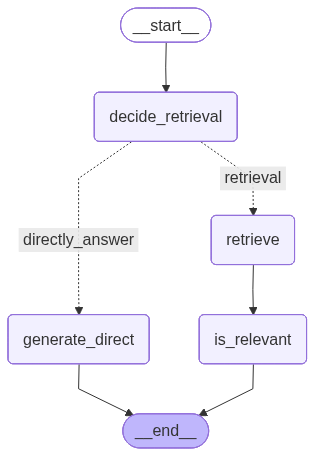

In [32]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)
g.add_node("is_relevant", is_relevant)

g.add_edge(START, "decide_retrieval")
g.add_conditional_edges("decide_retrieval", route_after_decide, {
    "retrieval": "retrieve", "directly_answer": "generate_direct"
})
g.add_edge("generate_direct", END)
g.add_edge("retrieve", "is_relevant")
g.add_edge("is_relevant", END)

app = g.compile()
app


In [34]:
res = app.invoke({"question": "Who is founder of apple"})

res['need_retrieval']
print(res["answer"])

The founder of Apple Inc. is Steve Jobs, along with Steve Wozniak and Ronald Wayne. They established the company on April 1, 1976.
